In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# train.csv 파일 로드(ID제외)
train = pd.read_csv('Data/train.csv').drop(columns=['ID'])

# 1. 데이터 구조 및 유형 확인

# 데이터 형태 확인
print("데이터 형태:", train.shape)

# 변수 종류 확인
print("변수 종류:")
print(train.dtypes)

데이터 형태: (256351, 68)
변수 종류:
시술 시기 코드                  object
시술 당시 나이                  object
임신 시도 또는 마지막 임신 경과 연수    float64
시술 유형                     object
특정 시술 유형                  object
                          ...   
난자 해동 경과일                float64
난자 혼합 경과일                float64
배아 이식 경과일                float64
배아 해동 경과일                float64
임신 성공 여부                   int64
Length: 68, dtype: object


결측치:


c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 510

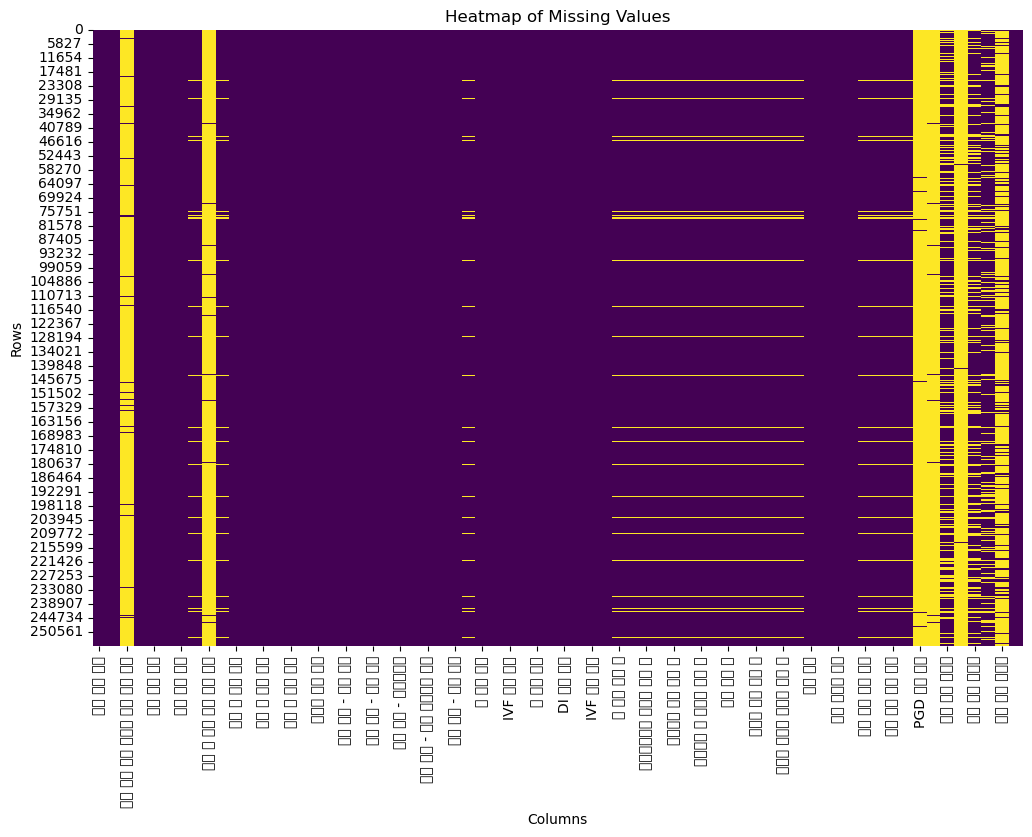

In [6]:
# 결측치 시각화
print("결측치:")
plt.figure(figsize=(12, 8))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

기술 통계:
       임신 시도 또는 마지막 임신 경과 연수       배란 자극 여부    단일 배아 이식 여부  착상 전 유전 검사 사용 여부  \
count            9370.000000  256351.000000  250060.000000            2718.0   
mean                9.270651       0.771286       0.233476               1.0   
std                 3.550313       0.420005       0.423043               0.0   
min                 0.000000       0.000000       0.000000               1.0   
25%                 7.000000       1.000000       0.000000               1.0   
50%                 9.000000       1.000000       0.000000               1.0   
75%                11.000000       1.000000       0.000000               1.0   
max                20.000000       1.000000       1.000000               1.0   

       착상 전 유전 진단 사용 여부     남성 주 불임 원인     남성 부 불임 원인     여성 주 불임 원인  \
count     250060.000000  256351.000000  256351.000000  256351.000000   
mean           0.012781       0.028516       0.013115       0.030724   
std            0.112328       0.166441       0.113767   

C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3418508634.py:34: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3418508634.py:34: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3418508634.py:34: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3418508634.py:34: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3418508634.py:34: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font

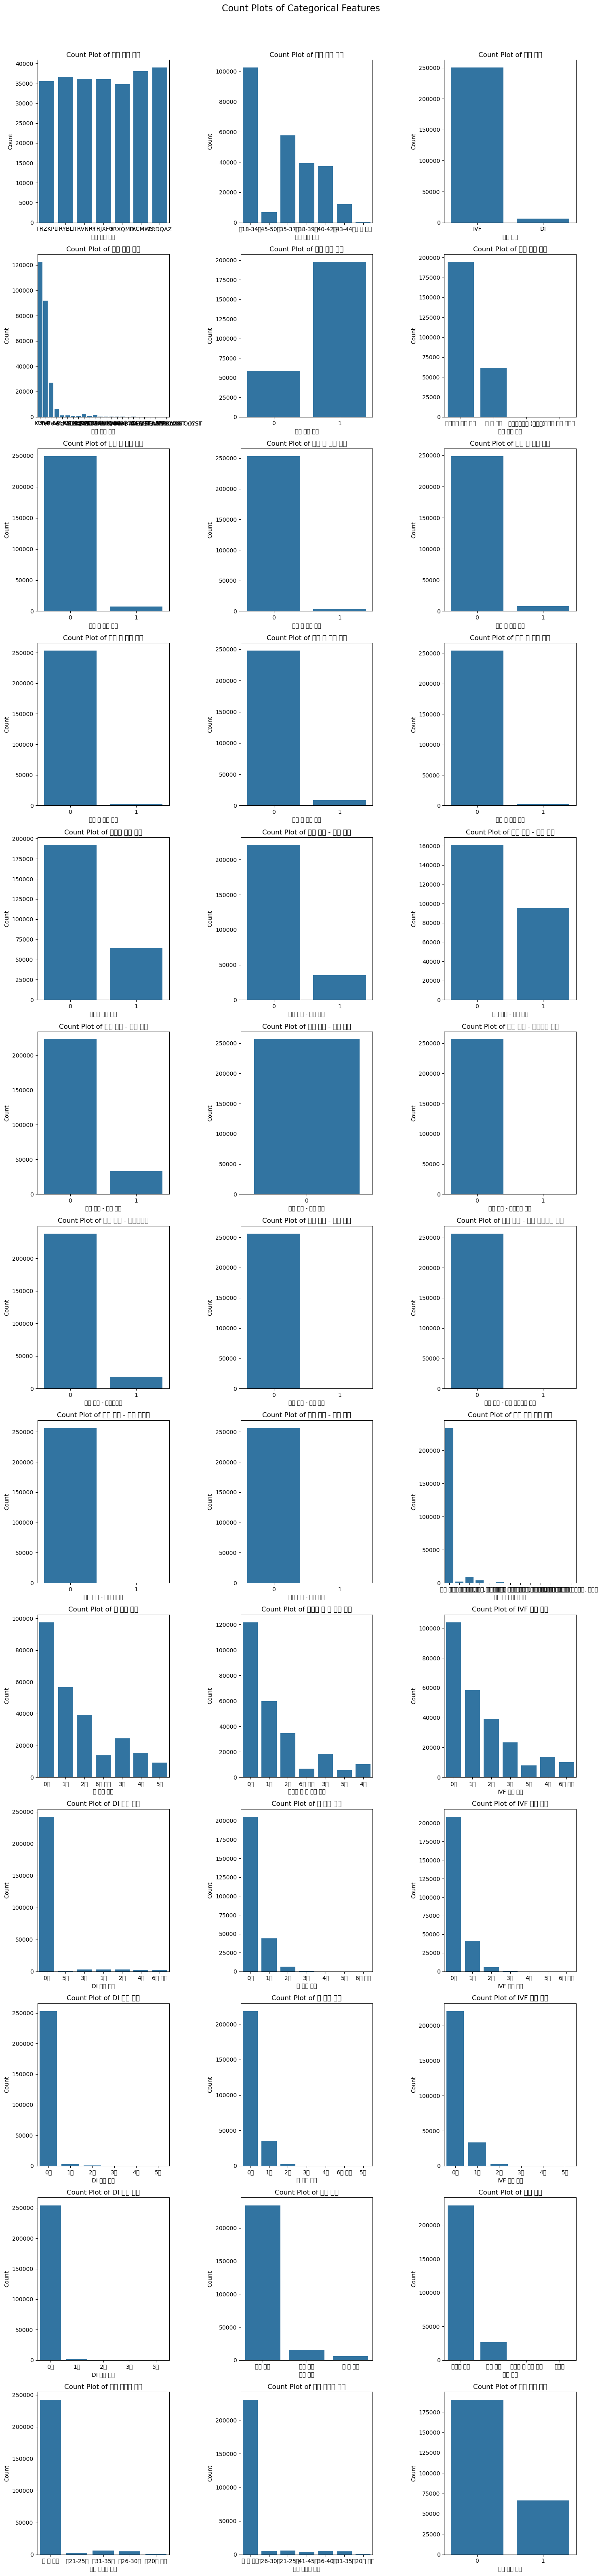

In [15]:
import math
# 2. 데이터 통계 및 시각화

# 기술 통계 확인
print("기술 통계:")
print(train.describe())

categorical_cols = train.select_dtypes(include=['object', 'int64']).columns
numerical_cols = train.select_dtypes(include=['float64']).columns

num_cols = len(categorical_cols)
num_rows = math.ceil(num_cols / 3)  # 예시: 3열로 배치, 필요에 따라 조정

# 전체 Figure 및 Subplots 생성
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows)) # figsize 조정

# 전체 Figure 제목 (옵션)
fig.suptitle('Count Plots of Categorical Features', fontsize=16)

# 각 subplot에 countplot 그리기
for i, col in enumerate(categorical_cols):
    ax = axes[i // 3, i % 3]  # 행, 열 인덱스 계산
    sns.countplot(data=train, x=col, ax=ax) # ax 파라미터에 subplot 지정
    ax.set_title(f'Count Plot of {col}') # subplot 제목 설정 (옵션)
    ax.tick_params(axis='x', labelsize=10) # x축 레이블 설정 (옵션)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

# 빈 subplot 제거 및 레이아웃 조정
if num_cols < num_rows * 3: # subplot이 부족한 경우 빈 subplot 제거
    for j in range(num_cols, num_rows * 3):
        fig.delaxes(axes.flatten()[j]) # 빈 subplot 삭제

plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
plt.show()


C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3302326854.py:23: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3302326854.py:23: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3302326854.py:23: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3302326854.py:23: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_8000\3302326854.py:23: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\jiwoo\AppData\Local\Temp\ipyk

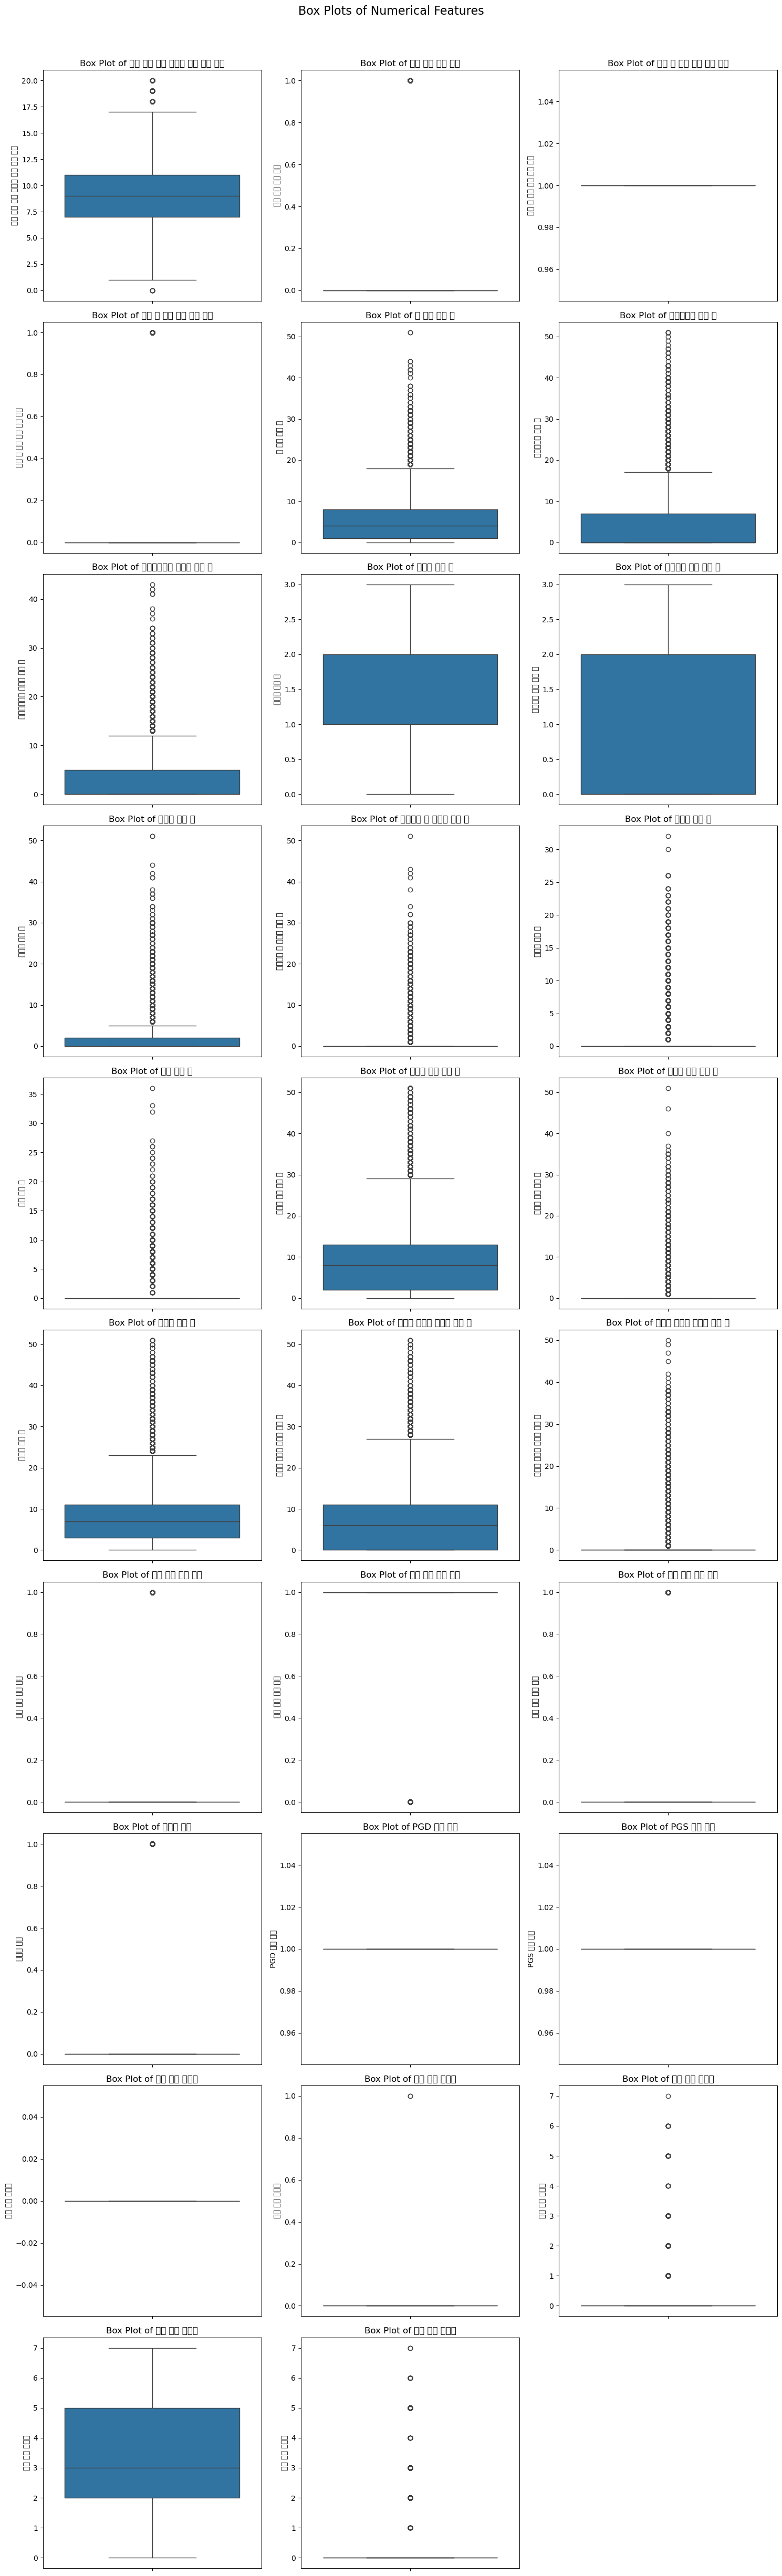

In [14]:
# subplot 행과 열 계산 (Count Plot과 동일한 로직)
num_cols = len(numerical_cols)
num_rows = math.ceil(num_cols / 3) # 예시: 3열 배치

# 전체 Figure 및 Subplots 생성
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows))

# 전체 Figure 제목 (옵션)
fig.suptitle('Box Plots of Numerical Features', fontsize=16)

# 각 subplot에 boxplot 그리기 (Count Plot 코드와 거의 동일)
for i, col in enumerate(numerical_cols):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=train, y=train[col], ax=ax) # boxplot으로 변경, y축 지정
    ax.set_title(f'Box Plot of {col}')
    ax.set_ylabel(col, fontsize=10) # y축 레이블 설정 (boxplot은 y축이 특성)

# 빈 subplot 제거 및 레이아웃 조정 (Count Plot과 동일)
if num_cols < num_rows * 3:
    for j in range(num_cols, num_rows * 3):
        fig.delaxes(axes.flatten()[j])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing f

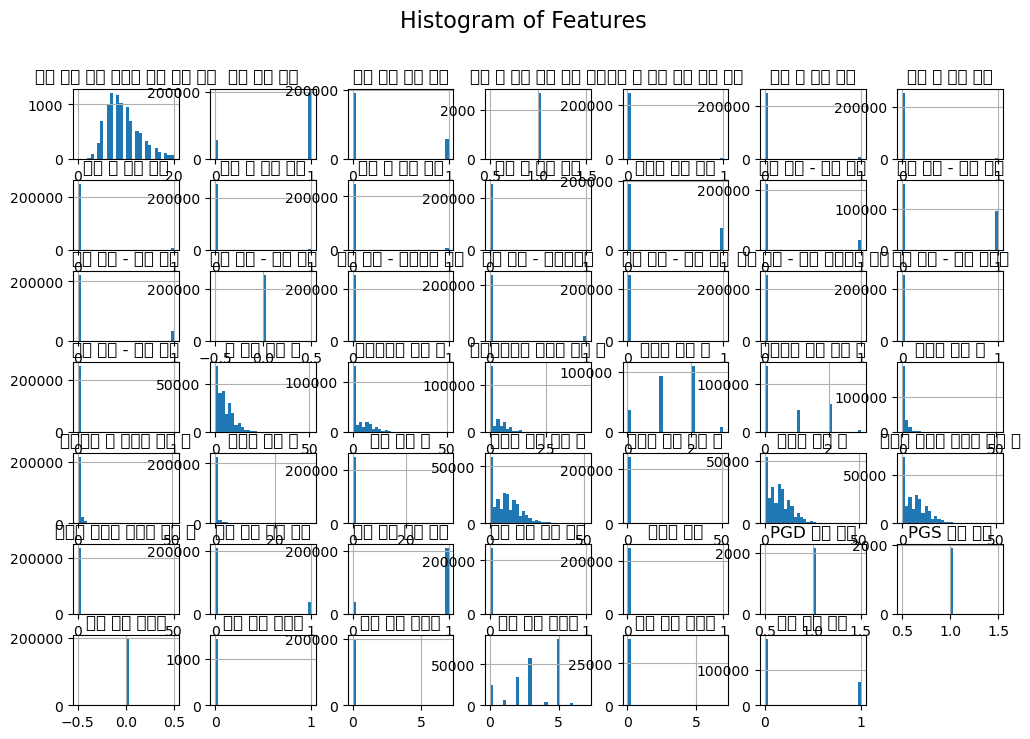

c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jiwoo\anaconda3\envs\aimers\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing f

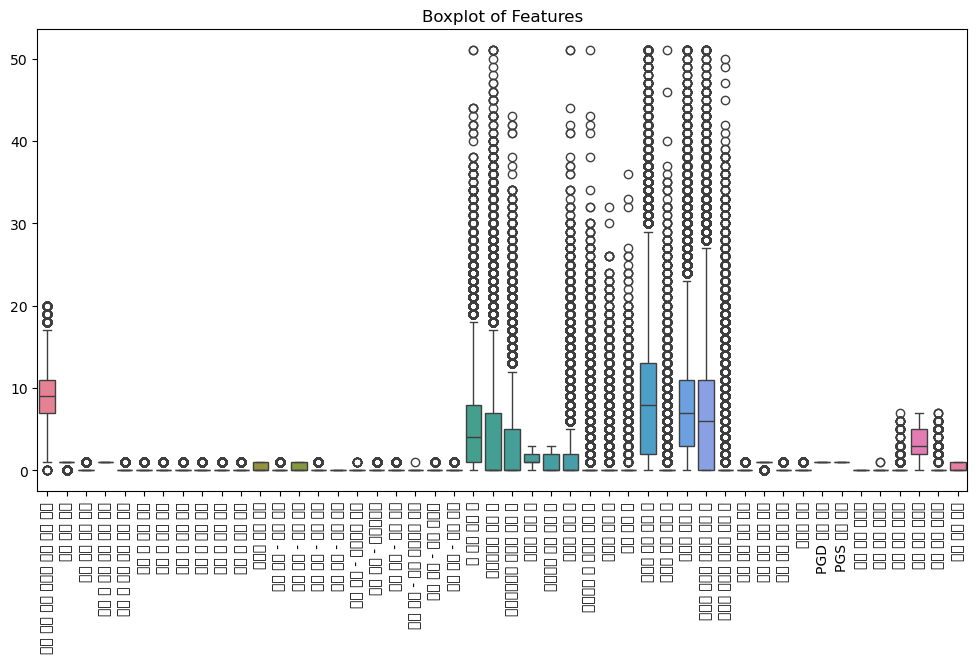

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

<Figure size 600x600 with 0 Axes>

In [16]:
import scipy.stats as stats
# 1. 히스토그램 (Histogram) - 각 특성의 분포 확인
train.hist(figsize=(12, 8), bins=30)
plt.suptitle("Histogram of Features", fontsize=16)
plt.show()

# 2. 박스플롯 (Box Plot) - 이상치 탐색
plt.figure(figsize=(12, 6))
sns.boxplot(data=train)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

# 3. Q-Q Plot - 정규성 확인 (특정 변수 예시)
feature = train.columns[0]  # 첫 번째 컬럼을 예시로 사용
plt.figure(figsize=(6, 6))
stats.probplot(train[feature].dropna(), dist="norm", plot=plt)
plt.title(f"Q-Q Plot of {feature}")
plt.show()

In [ ]:

# 산점도
# (예시: 'feature1'과 'feature2' 변수 간의 산점도)


# (선택) 추가적인 시각화
# - box plot: train.boxplot()
# - pair plot: sns.pairplot(train)
# - correlation matrix: train.corr() heatmap으로 시각화

# (선택) 특정 변수에 대한 심층 분석
# 예시: 'target' 변수의 분포
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=train)
plt.title('Distribution of Target Variable')
plt.show()

# 예시: 'feature3' 변수의 값에 따른 'target' 변수의 변화
plt.figure(figsize=(8, 6))
sns.boxplot(x='feature3', y='target', data=train)
plt.title('Target Variable by Feature 3')
plt.show()